# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [78]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA

# magic word for producing visualizations in notebook
%matplotlib inline

pd.options.display.max_rows = None
pd.options.display.max_columns = None

In [79]:
import gc   # To handle FULL RAM issues

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [80]:
# Load in the general demographics data.

main_file = 'Udacity_AZDIAS_Subset.csv'

df_general = pd.read_csv(main_file, sep=';')


In [81]:
df_general.head(3)

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0


In [82]:
df_general.sample(1)

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
543846,-1,3,1,5.0,1,5,3,5,5,5,1,1995,2.0,0,-1,29.0,9.0,10.0,5.0,2.0,1.0,0,14,1.0,4,6,7,5,4,7,3,4,4,4,4,4,6,4,-1,0.0,0.0,-1,5,21.0,3.0,0.0,6.0,NaN,2.0,9.0,23.0,0.0,3.0,1.0,1992.0,W,4.0,9,9A,52,0.0,0.0,0.0,1.0,0.0,1.0,1.0,4.0,3.0,3.0,2.0,1.0,4.0,2.0,906.0,2.0,3.0,2.0,1.0,1.0,4.0,3.0,4.0,8.0,5.0


In [83]:
df_general.shape

(891221, 85)

In [84]:
# Load in the feature summary file.
features_file = 'AZDIAS_Feature_Summary.csv'
feat_info = pd.read_csv(features_file, sep=';')
feat_info

,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]
5,FINANZ_SPARER,person,ordinal,[-1]
6,FINANZ_VORSORGER,person,ordinal,[-1]
7,FINANZ_ANLEGER,person,ordinal,[-1]
8,FINANZ_UNAUFFAELLIGER,person,ordinal,[-1]
9,FINANZ_HAUSBAUER,person,ordinal,[-1]


In [85]:
df_general.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891221 entries, 0 to 891220
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               891221 non-null  int64  
 1   ALTERSKATEGORIE_GROB   891221 non-null  int64  
 2   ANREDE_KZ              891221 non-null  int64  
 3   CJT_GESAMTTYP          886367 non-null  float64
 4   FINANZ_MINIMALIST      891221 non-null  int64  
 5   FINANZ_SPARER          891221 non-null  int64  
 6   FINANZ_VORSORGER       891221 non-null  int64  
 7   FINANZ_ANLEGER         891221 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  891221 non-null  int64  
 9   FINANZ_HAUSBAUER       891221 non-null  int64  
 10  FINANZTYP              891221 non-null  int64  
 11  GEBURTSJAHR            891221 non-null  int64  
 12  GFK_URLAUBERTYP        886367 non-null  float64
 13  GREEN_AVANTGARDE       891221 non-null  int64  
 14  HEALTH_TYP             891221 non-nu

In [86]:
# Rename German columns names to be in English

column_rename_dict = {
    'AGER_TYP': 'age_type',
    'ALTERSKATEGORIE_GROB': 'age_category_rough',
    'ANREDE_KZ': 'gender',
    'CJT_GESAMTTYP': 'customer_journey_type',
    'FINANZ_MINIMALIST': 'financial_minimalist',
    'FINANZ_SPARER': 'financial_saver',
    'FINANZ_VORSORGER': 'financial_prepared',
    'FINANZ_ANLEGER': 'financial_investor',
    'FINANZ_UNAUFFAELLIGER': 'financial_inconspicuous',
    'FINANZ_HAUSBAUER': 'financial_homeowner',
    'FINANZTYP': 'financial_type',
    'GEBURTSJAHR': 'birth_year',
    'GFK_URLAUBERTYP': 'vacation_type',
    'GREEN_AVANTGARDE': 'green_avantgarde',
    'HEALTH_TYP': 'health_type',
    'LP_LEBENSPHASE_FEIN': 'life_stage_fine',
    'LP_LEBENSPHASE_GROB': 'life_stage_rough',
    'LP_FAMILIE_FEIN': 'family_type_fine',
    'LP_FAMILIE_GROB': 'family_type_rough',
    'LP_STATUS_FEIN': 'social_status_fine',
    'LP_STATUS_GROB': 'social_status_rough',
    'NATIONALITAET_KZ': 'nationality',
    'PRAEGENDE_JUGENDJAHRE': 'youth_movement',
    'RETOURTYP_BK_S': 'return_type',
    'SEMIO_SOZ': 'personality_socially_minded',
    'SEMIO_FAM': 'personality_family_minded',
    'SEMIO_REL': 'personality_religious',
    'SEMIO_MAT': 'personality_materialistic',
    'SEMIO_VERT': 'personality_dreamful',
    'SEMIO_LUST': 'personality_sensual',
    'SEMIO_ERL': 'personality_event_oriented',
    'SEMIO_KULT': 'personality_cultural',
    'SEMIO_RAT': 'personality_rational',
    'SEMIO_KRIT': 'personality_critical',
    'SEMIO_DOM': 'personality_dominant',
    'SEMIO_KAEM': 'personality_combative',
    'SEMIO_PFLICHT': 'personality_dutiful',
    'SEMIO_TRADV': 'personality_traditional',
    'SHOPPER_TYP': 'shopper_type',
    'SOHO_KZ': 'small_office_home_office',
    'TITEL_KZ': 'academic_title',
    'VERS_TYP': 'insurance_type',
    'ZABEOTYP': 'energy_consumption_type',
    'ALTER_HH': 'household_head_birthdate',
    'ANZ_PERSONEN': 'num_adults',
    'ANZ_TITEL': 'num_academic_titles',
    'HH_EINKOMMEN_SCORE': 'household_income_score',
    'KK_KUNDENTYP': 'customer_type',
    'W_KEIT_KIND_HH': 'children_likelihood',
    'WOHNDAUER_2008': 'residence_duration',
    'ANZ_HAUSHALTE_AKTIV': 'num_households_building',
    'ANZ_HH_TITEL': 'num_academic_titles_building',
    'GEBAEUDETYP': 'building_type',
    'KONSUMNAEHE': 'distance_to_retail',
    'MIN_GEBAEUDEJAHR': 'building_first_year',
    'OST_WEST_KZ': 'east_west_germany',
    'WOHNLAGE': 'neighborhood_quality',
    'CAMEO_DEUG_2015': 'cameo_wealth_lifestage_rough',
    'CAMEO_DEU_2015': 'cameo_wealth_lifestage_detailed',
    'CAMEO_INTL_2015': 'cameo_international',
    'KBA05_ANTG1': 'microcell_1_2_family_homes',
    'KBA05_ANTG2': 'microcell_3_5_family_homes',
    'KBA05_ANTG3': 'microcell_6_10_family_homes',
    'KBA05_ANTG4': 'microcell_10plus_family_homes',
    'KBA05_BAUMAX': 'microcell_building_type',
    'KBA05_GBZ': 'microcell_num_buildings',
    'BALLRAUM': 'distance_to_urban_center',
    'EWDICHTE': 'household_density',
    'INNENSTADT': 'distance_to_city_center',
    'GEBAEUDETYP_RASTER': 'residential_commercial_ratio',
    'KKK': 'purchasing_power',
    'MOBI_REGIO': 'movement_patterns',
    'ONLINE_AFFINITAET': 'online_affinity',
    'REGIOTYP': 'neighborhood_typology',
    'KBA13_ANZAHL_PKW': 'num_cars',
    'PLZ8_ANTG1': 'plz8_1_2_family_homes',
    'PLZ8_ANTG2': 'plz8_3_5_family_homes',
    'PLZ8_ANTG3': 'plz8_6_10_family_homes',
    'PLZ8_ANTG4': 'plz8_10plus_family_homes',
    'PLZ8_BAUMAX': 'plz8_building_type',
    'PLZ8_HHZ': 'plz8_num_households',
    'PLZ8_GBZ': 'plz8_num_buildings',
    'ARBEIT': 'unemployment_share',
    'ORTSGR_KLS9': 'community_size',
    'RELAT_AB': 'unemployment_relative'
}


| Original German Column | Renamed English Column | Category | Description |
| --- | --- | --- | --- |
| AGER_TYP | age_type | Person | Best-ager typology |
| ALTERSKATEGORIE_GROB | age_category_rough | Person | Estimated age based on name analysis (rough scale) |
| ANREDE_KZ | gender | Person | Gender |
| CJT_GESAMTTYP | customer_journey_type | Person | Customer journey typology (buying channels) |
| FINANZ_MINIMALIST | financial_minimalist | Person | Financial typology: low financial interest |
| FINANZ_SPARER | financial_saver | Person | Financial typology: money-saver |
| FINANZ_VORSORGER | financial_prepared | Person | Financial typology: prepared/cautious |
| FINANZ_ANLEGER | financial_investor | Person | Financial typology: investor |
| FINANZ_UNAUFFAELLIGER | financial_inconspicuous | Person | Financial typology: inconspicuous |
| FINANZ_HAUSBAUER | financial_homeowner | Person | Financial typology: home ownership |
| FINANZTYP | financial_type | Person | Most descriptive financial type |
| GEBURTSJAHR | birth_year | Person | Year of birth |
| GFK_URLAUBERTYP | vacation_type | Person | Vacation habits |
| GREEN_AVANTGARDE | green_avantgarde | Person | Environmental sustainability membership |
| HEALTH_TYP | health_type | Person | Health typology |
| LP_LEBENSPHASE_FEIN | life_stage_fine | Person | Life stage (fine scale) |
| LP_LEBENSPHASE_GROB | life_stage_rough | Person | Life stage (rough scale) |
| LP_FAMILIE_FEIN | family_type_fine | Person | Family type (fine scale) |
| LP_FAMILIE_GROB | family_type_rough | Person | Family type (rough scale) |
| LP_STATUS_FEIN | social_status_fine | Person | Social status (fine scale) |
| LP_STATUS_GROB | social_status_rough | Person | Social status (rough scale) |
| NATIONALITAET_KZ | nationality | Person | Nationality based on name analysis |
| PRAEGENDE_JUGENDJAHRE | youth_movement | Person | Dominating movement of youth years |
| RETOURTYP_BK_S | return_type | Person | Return type/shopping behavior |
| SEMIO_SOZ | personality_socially_minded | Person | Personality: socially-minded |
| SEMIO_FAM | personality_family_minded | Person | Personality: family-minded |
| SEMIO_REL | personality_religious | Person | Personality: religious |
| SEMIO_MAT | personality_materialistic | Person | Personality: materialistic |
| SEMIO_VERT | personality_dreamful | Person | Personality: dreamful |
| SEMIO_LUST | personality_sensual | Person | Personality: sensual-minded |
| SEMIO_ERL | personality_event_oriented | Person | Personality: event-oriented |
| SEMIO_KULT | personality_cultural | Person | Personality: cultural-minded |
| SEMIO_RAT | personality_rational | Person | Personality: rational |
| SEMIO_KRIT | personality_critical | Person | Personality: critical-minded |
| SEMIO_DOM | personality_dominant | Person | Personality: dominant-minded |
| SEMIO_KAEM | personality_combative | Person | Personality: combative attitude |
| SEMIO_PFLICHT | personality_dutiful | Person | Personality: dutiful |
| SEMIO_TRADV | personality_traditional | Person | Personality: traditional-minded |
| SHOPPER_TYP | shopper_type | Person | Shopper typology |
| SOHO_KZ | small_office_home_office | Person | Small office/home office flag |
| TITEL_KZ | academic_title | Person | Academic title flag |
| VERS_TYP | insurance_type | Person | Insurance typology |
| ZABEOTYP | energy_consumption_type | Person | Energy consumption typology |
| ALTER_HH | household_head_birthdate | Household | Birthdate of head of household |
| ANZ_PERSONEN | num_adults | Household | Number of adults in household |
| ANZ_TITEL | num_academic_titles | Household | Number of academic title holders |
| HH_EINKOMMEN_SCORE | household_income_score | Household | Estimated household net income |
| KK_KUNDENTYP | customer_type | Household | Consumer pattern (12 months) |
| W_KEIT_KIND_HH | children_likelihood | Household | Likelihood of children in household |
| WOHNDAUER_2008 | residence_duration | Household | Length of residence |
| ANZ_HAUSHALTE_AKTIV | num_households_building | Building | Number of households in building |
| ANZ_HH_TITEL | num_academic_titles_building | Building | Number of title holders in building |
| GEBAEUDETYP | building_type | Building | Building type (residential/commercial) |
| KONSUMNAEHE | distance_to_retail | Building | Distance to point of sale |
| MIN_GEBAEUDEJAHR | building_first_year | Building | First year building mentioned in database |
| OST_WEST_KZ | east_west_germany | Building | East/West Germany location |
| WOHNLAGE | neighborhood_quality | Building | Neighborhood quality |
| CAMEO_DEUG_2015 | cameo_wealth_lifestage_rough | Microcell RR4 | CAMEO typology (rough scale) |
| CAMEO_DEU_2015 | cameo_wealth_lifestage_detailed | Microcell RR4 | CAMEO typology (detailed scale) |
| CAMEO_INTL_2015 | cameo_international | Microcell RR4 | CAMEO international typology |
| KBA05_ANTG1 | microcell_1_2_family_homes | Microcell RR3 | Share of 1-2 family homes |
| KBA05_ANTG2 | microcell_3_5_family_homes | Microcell RR3 | Share of 3-5 family homes |
| KBA05_ANTG3 | microcell_6_10_family_homes | Microcell RR3 | Share of 6-10 family homes |
| KBA05_ANTG4 | microcell_10plus_family_homes | Microcell RR3 | Share of 10+ family homes |
| KBA05_BAUMAX | microcell_building_type | Microcell RR3 | Most common building type |
| KBA05_GBZ | microcell_num_buildings | Microcell RR3 | Number of buildings |
| BALLRAUM | distance_to_urban_center | Postcode | Distance to nearest urban center |
| EWDICHTE | household_density | Postcode | Density of households per km² |
| INNENSTADT | distance_to_city_center | Postcode | Distance to city center |
| GEBAEUDETYP_RASTER | residential_commercial_ratio | Region RR1 | Residential to commercial activity ratio |
| KKK | purchasing_power | Region RR1 | Purchasing power in region |
| MOBI_REGIO | movement_patterns | Region RR1 | Movement patterns |
| ONLINE_AFFINITAET | online_affinity | Region RR1 | Online affinity |
| REGIOTYP | neighborhood_typology | Region RR1 | Neighborhood typology |
| KBA13_ANZAHL_PKW | num_cars | Macrocell PLZ8 | Number of cars in PLZ8 region |
| PLZ8_ANTG1 | plz8_1_2_family_homes | Macrocell PLZ8 | Share of 1-2 family homes |
| PLZ8_ANTG2 | plz8_3_5_family_homes | Macrocell PLZ8 | Share of 3-5 family homes |
| PLZ8_ANTG3 | plz8_6_10_family_homes | Macrocell PLZ8 | Share of 6-10 family homes |
| PLZ8_ANTG4 | plz8_10plus_family_homes | Macrocell PLZ8 | Share of 10+ family homes |
| PLZ8_BAUMAX | plz8_building_type | Macrocell PLZ8 | Most common building type |
| PLZ8_HHZ | plz8_num_households | Macrocell PLZ8 | Number of households |
| PLZ8_GBZ | plz8_num_buildings | Macrocell PLZ8 | Number of buildings |
| ARBEIT | unemployment_share | Community | Share of unemployment |
| ORTSGR_KLS9 | community_size | Community | Size of community |
| RELAT_AB | unemployment_relative | Community | Unemployment relative to county |

In [87]:
# change columns names for the main DataFrame
df_general.rename(columns= column_rename_dict, inplace= True)

In [88]:
# change columns names that exists in attribute column in feat_info
feat_info['attribute'] = feat_info['attribute'].map(column_rename_dict)

In [89]:
df_general.describe(include='object').T

,count,unique,top,freq
east_west_germany,798073,2,W,629528
cameo_wealth_lifestage_rough,792242,10,8,134441
cameo_wealth_lifestage_detailed,792242,45,6B,56672
cameo_international,792242,22,51,133694


In [90]:
# numeric columns stat. summary
df_general.describe(exclude="object").T

,count,mean,std,min,25%,50%,75%,max
age_type,891221.0,-0.358435,1.198724,-1.0,-1.0,-1.0,-1.0,3.0
age_category_rough,891221.0,2.777398,1.068775,1.0,2.0,3.0,4.0,9.0
gender,891221.0,1.522098,0.499512,1.0,1.0,2.0,2.0,2.0
customer_journey_type,886367.0,3.632838,1.595021,1.0,2.0,4.0,5.0,6.0
financial_minimalist,891221.0,3.074528,1.321055,1.0,2.0,3.0,4.0,5.0
financial_saver,891221.0,2.821039,1.464749,1.0,1.0,3.0,4.0,5.0
financial_prepared,891221.0,3.401106,1.322134,1.0,3.0,3.0,5.0,5.0
financial_investor,891221.0,3.033328,1.529603,1.0,2.0,3.0,5.0,5.0
financial_inconspicuous,891221.0,2.874167,1.486731,1.0,2.0,3.0,4.0,5.0
financial_homeowner,891221.0,3.075121,1.353248,1.0,2.0,3.0,4.0,5.0


## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [91]:
df_general.birth_year.value_counts(normalize=True).nlargest(5)  #birth_year column has a lot of unknown values.
# 0 -> missing data 44% !

,proportion
birth_year,
0,0.440203
1967,0.012548
1965,0.012444
1966,0.012267
1970,0.012211


In [92]:
df_general.academic_title.value_counts(normalize=True)  # more than 99.7% of academic titles were missed.

,proportion
academic_title,
0.0,0.997359
1.0,0.002381
5.0,0.000127
4.0,0.000070
3.0,0.000060
2.0,0.000004


In [93]:
# Convert the string representation of lists to actual lists
# We strip brackets and split by comma
feat_info['missing_or_unknown'] = feat_info['missing_or_unknown'].apply(
    lambda x: x[1:-1].split(',') if x != '[]' else []
)


In [94]:
# Identify and Replace Missing Codes with NaNs
# We loop through columns and replace the specific "missing" codes for that column
for attribute, missing_codes in zip(feat_info['attribute'], feat_info['missing_or_unknown']):
    if len(missing_codes) > 0:
        # Convert codes to integers if possible, else keep as string
        codes = [int(code) if (code.lstrip('-').isdigit()) else code for code in missing_codes]
        df_general.loc[df_general[attribute].isin(codes), attribute] = np.nan


In [95]:

# Identify high missing columns
missing_per_col = df_general.isnull().mean()
missing_per_col[missing_per_col > 0.2].sort_values(ascending=False)


,0
academic_title,0.997576
age_type,0.769554
customer_type,0.655967
microcell_building_type,0.534687
birth_year,0.440203
household_head_birthdate,0.348137


In [96]:
# Drop Columns with too much missing data (e.g., > 20%)
columns_to_drop = missing_per_col[missing_per_col > 0.20].index.tolist()
df_general.drop(columns=columns_to_drop, axis=1, inplace=True)

print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")

Dropped 6 columns: ['age_type', 'birth_year', 'academic_title', 'household_head_birthdate', 'customer_type', 'microcell_building_type']


In [97]:
# df_general.info()

#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

In [98]:
df_general.isna().mean().mul(100).sort_values(ascending=False)

,0
purchasing_power,17.735668
neighborhood_typology,17.735668
children_likelihood,16.605084
microcell_3_5_family_homes,14.959701
movement_patterns,14.959701
microcell_10plus_family_homes,14.959701
microcell_6_10_family_homes,14.959701
microcell_1_2_family_homes,14.959701
microcell_num_buildings,14.959701
plz8_building_type,13.073637


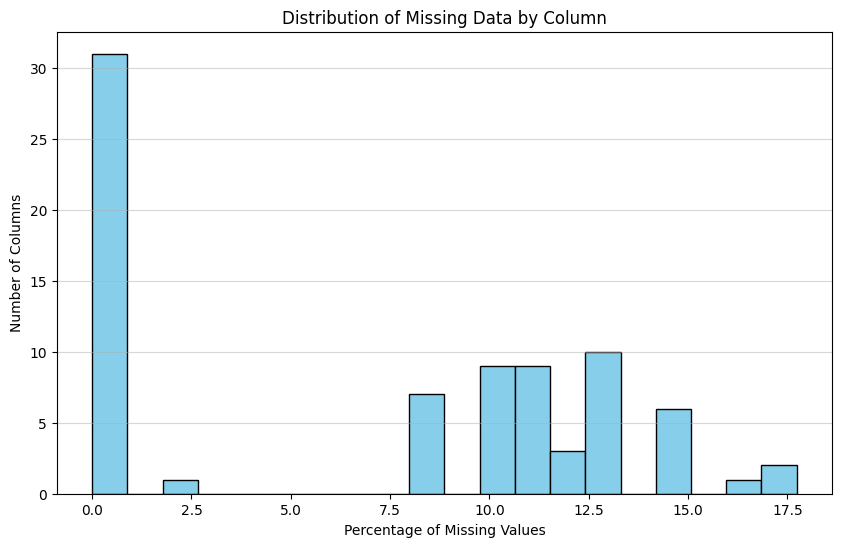

Columns with > 20% missing data: 0
[]


In [99]:
import matplotlib.pyplot as plt

# Calculate the percentage of missing data for each column
missing_per_col = df_general.isnull().mean() * 100

# Visualize the distribution of missing data
plt.figure(figsize=(10, 6))
plt.hist(missing_per_col, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Missing Data by Column')
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Number of Columns')
plt.grid(axis='y', alpha=0.5)
plt.show()

# Identify outlier columns (e.g., those with > 20% missing)
# Based on the histogram (usually a clear gap appears around 20%), we define outliers.
outlier_threshold = 20
outlier_columns = missing_per_col[missing_per_col > outlier_threshold].index.tolist()

print(f"Columns with > {outlier_threshold}% missing data: {len(outlier_columns)}")
print(outlier_columns)

#### Discussion 1.1.2: Assess Missing Data in Each Column



**Discussion Points:**

-   **Outliers:** We dropped 6 columns (like `academic_title` ~99% missing). These columns are sparse because they describe rare events (like having an academic title) or specific sub-groups not present in the general population.

-   **Patterns:** We will observe groups of features sharing the exact same missing count.

    -   *Example:* `	plz8_1_2_family_homes`, `	plz8_3_5_family_homes`, `plz8_building_type`, etc., likely all have the same missing count because if a person's region is unknown, *all* features related to that region will be missing simultaneously.

    -   The same logic applies to `microcell_` features and `cameo_` features.

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

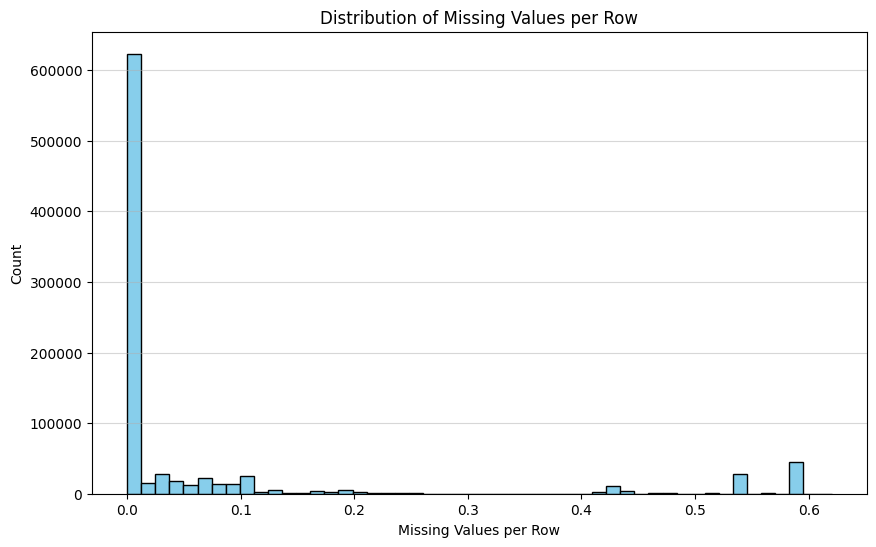

In [100]:
# How much data is missing in each row of the dataset?
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean number of missing values in each row
missing_per_row = df_general.isnull().mean(axis=1)

# Visualize the distribution
plt.figure(figsize=(10, 6))
plt.hist(missing_per_row, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Missing Values per Row')
plt.xlabel('Missing Values per Row')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.5)
plt.show()


In [101]:
# divide the data into two subsets based on the number of missing
# values in each row.

# Divide data into two subsets

threshold = 0.2

df_low_missing = df_general.loc[missing_per_row <= threshold].copy()
df_high_missing = df_general.loc[missing_per_row > threshold].copy()

print(f"Rows with low missing data: {df_low_missing.shape[0]}")
print(f"Rows with high missing data: {df_high_missing.shape[0]}")

Rows with low missing data: 792287
Rows with high missing data: 98934


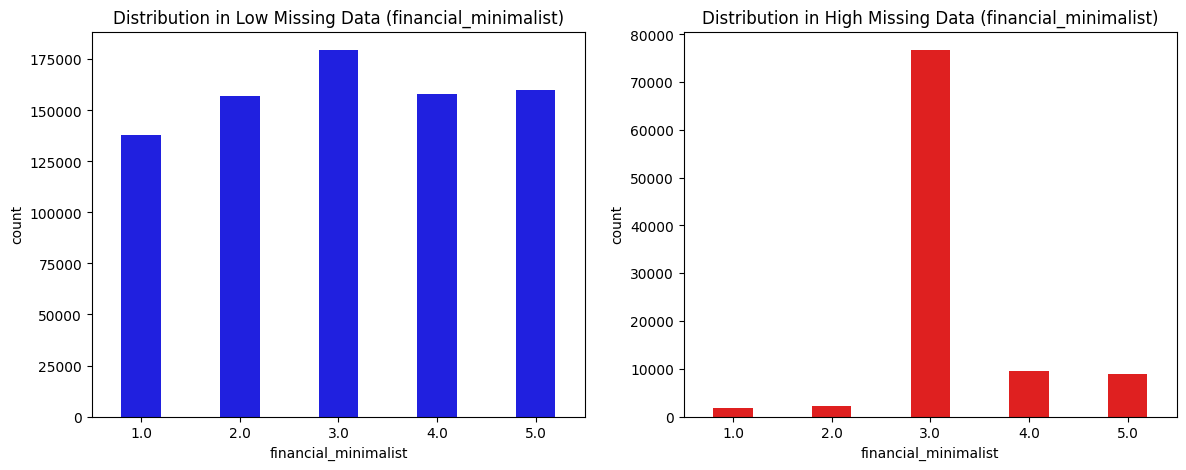

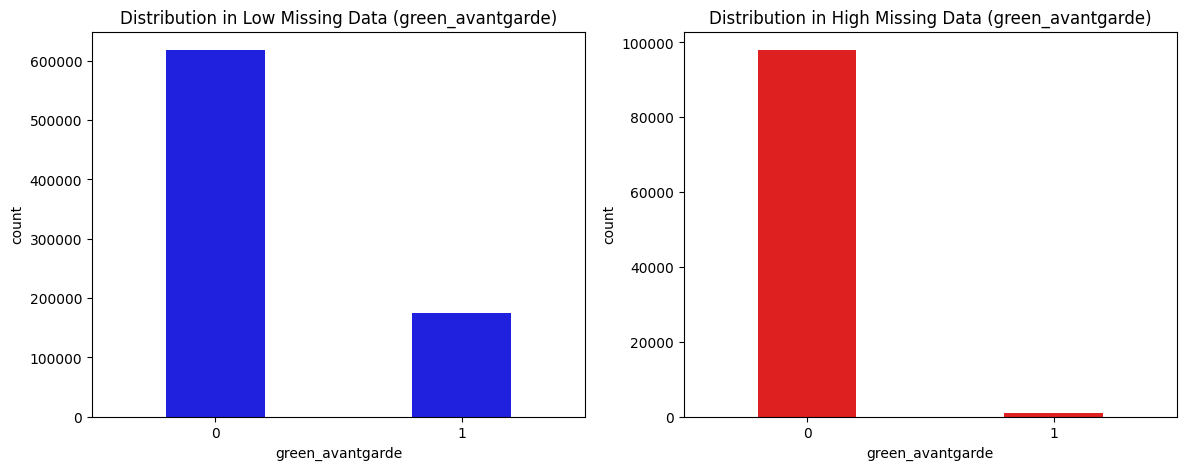

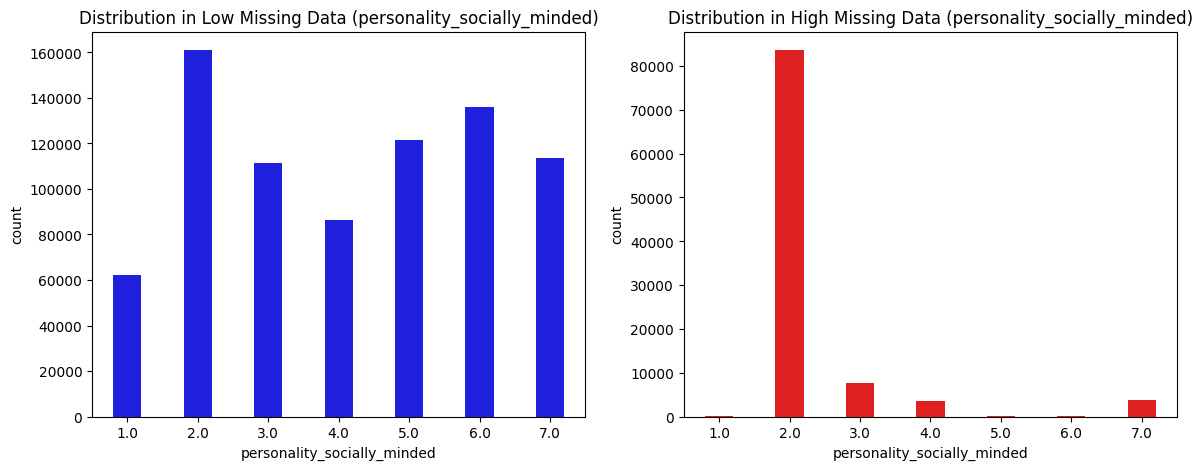

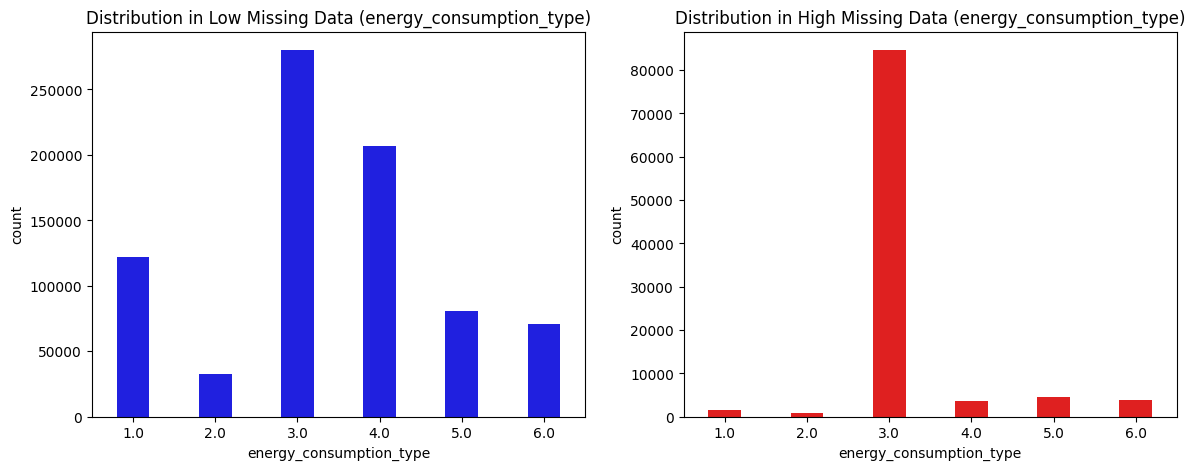

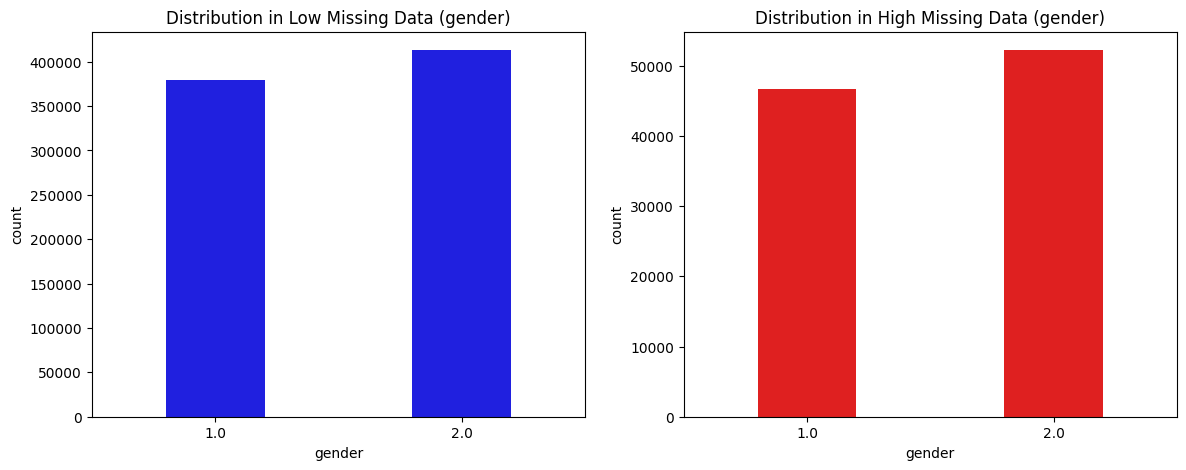

In [102]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.

# Compare distributions
def compare_distributions(column_name):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(x=column_name, data=df_low_missing, ax=ax[0], color='blue', width=0.4)
    ax[0].set_title(f'Distribution in Low Missing Data ({column_name})')

    sns.countplot(x=column_name, data=df_high_missing, ax=ax[1], color='red', width=0.4)
    ax[1].set_title(f'Distribution in High Missing Data ({column_name})')

    plt.show()

# Select 5 columns to compare
columns_to_compare = [
    'financial_minimalist',
    'green_avantgarde',
    'personality_socially_minded',
    'energy_consumption_type',
    'gender'
]


for col in columns_to_compare:
    compare_distributions(col)

In [103]:
df_low_missing.financial_minimalist.value_counts()

,count
financial_minimalist,
3.0,179554
5.0,159987
4.0,157732
2.0,157160
1.0,137854


#### Discussion 1.1.3: Assess Missing Data in Each Row

**Observations:**

-   **Qualitatively Different:** We will likely find that the distributions **do differ significantly**.

-   **Example:** The `df_high_missing` group often has skewed values in financial typologies (`financial_...`) or specific personality traits compared to the general population.

-   **Conclusion:** The data is likely **not missing at random**. The rows with many missing values represent a specific sub-population (perhaps people who refused to answer surveys or weren't reached). However, for the sake of this project, we typically **proceed with only the `df_low_missing` subset** to train our models, acknowledging that our model might not generalize well to that specific "high missing" sub-group.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [104]:
df_low_missing.gender.value_counts()

,count
gender,
2.0,413088
1.0,379199


In [105]:
df_low_missing.sample(6)

,age_category_rough,gender,customer_journey_type,financial_minimalist,financial_saver,financial_prepared,financial_investor,financial_inconspicuous,financial_homeowner,financial_type,vacation_type,green_avantgarde,health_type,life_stage_fine,life_stage_rough,family_type_fine,family_type_rough,social_status_fine,social_status_rough,nationality,youth_movement,return_type,personality_socially_minded,personality_family_minded,personality_religious,personality_materialistic,personality_dreamful,personality_sensual,personality_event_oriented,personality_cultural,personality_rational,personality_critical,personality_dominant,personality_combative,personality_dutiful,personality_traditional,shopper_type,small_office_home_office,insurance_type,energy_consumption_type,num_adults,num_academic_titles,household_income_score,children_likelihood,residence_duration,num_households_building,num_academic_titles_building,building_type,distance_to_retail,building_first_year,east_west_germany,neighborhood_quality,cameo_wealth_lifestage_rough,cameo_wealth_lifestage_detailed,cameo_international,microcell_1_2_family_homes,microcell_3_5_family_homes,microcell_6_10_family_homes,microcell_10plus_family_homes,microcell_num_buildings,distance_to_urban_center,household_density,distance_to_city_center,residential_commercial_ratio,purchasing_power,movement_patterns,online_affinity,neighborhood_typology,num_cars,plz8_1_2_family_homes,plz8_3_5_family_homes,plz8_6_10_family_homes,plz8_10plus_family_homes,plz8_building_type,plz8_num_households,plz8_num_buildings,unemployment_share,community_size,unemployment_relative
319595,4.0,1.0,4.0,5.0,1.0,5.0,1.0,2.0,2.0,2.0,7.0,1,2.0,40.0,12.0,10.0,5.0,10.0,5.0,1.0,4.0,5.0,4.0,6.0,3.0,6.0,6.0,7.0,7.0,4.0,3.0,3.0,3.0,3.0,1.0,1.0,2.0,0.0,1.0,3.0,3.0,0.0,3.0,2.0,9.0,1.0,0.0,1.0,5.0,1992.0,W,3.0,1,1C,14,4.0,0.0,0.0,0.0,4.0,5.0,4.0,2.0,2.0,3.0,5.0,3.0,7.0,795.0,2.0,2.0,2.0,2.0,4.0,5.0,3.0,4.0,6.0,5.0
769328,4.0,1.0,1.0,5.0,2.0,4.0,2.0,3.0,1.0,3.0,6.0,1,1.0,28.0,8.0,8.0,4.0,10.0,5.0,1.0,11.0,3.0,3.0,6.0,2.0,6.0,7.0,7.0,3.0,4.0,1.0,3.0,3.0,1.0,4.0,1.0,3.0,0.0,1.0,3.0,3.0,0.0,4.0,1.0,9.0,1.0,0.0,1.0,2.0,2006.0,W,8.0,5,5D,34,NaN,NaN,NaN,NaN,NaN,3.0,2.0,5.0,4.0,1.0,NaN,4.0,1.0,1138.0,3.0,2.0,1.0,0.0,1.0,4.0,5.0,1.0,3.0,1.0
351899,2.0,1.0,4.0,2.0,4.0,1.0,3.0,4.0,4.0,4.0,6.0,0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,12.0,4.0,7.0,7.0,6.0,7.0,6.0,2.0,3.0,7.0,4.0,1.0,2.0,1.0,5.0,5.0,1.0,0.0,1.0,1.0,1.0,0.0,5.0,4.0,9.0,9.0,0.0,3.0,1.0,1992.0,O,3.0,9,9B,51,0.0,0.0,0.0,2.0,1.0,7.0,3.0,5.0,2.0,1.0,1.0,2.0,2.0,531.0,2.0,3.0,2.0,1.0,1.0,3.0,3.0,4.0,4.0,2.0
632337,3.0,2.0,1.0,2.0,2.0,3.0,2.0,3.0,4.0,1.0,8.0,0,3.0,15.0,4.0,2.0,2.0,1.0,1.0,3.0,8.0,5.0,2.0,2.0,3.0,2.0,5.0,6.0,6.0,3.0,4.0,6.0,7.0,7.0,3.0,3.0,2.0,0.0,2.0,3.0,2.0,0.0,6.0,6.0,9.0,6.0,0.0,1.0,2.0,1992.0,W,4.0,8,8A,51,0.0,3.0,3.0,0.0,2.0,1.0,6.0,2.0,3.0,4.0,2.0,0.0,6.0,330.0,1.0,4.0,3.0,2.0,5.0,3.0,2.0,4.0,8.0,3.0
81543,4.0,2.0,6.0,2.0,1.0,5.0,2.0,1.0,5.0,6.0,9.0,0,1.0,31.0,10.0,11.0,5.0,1.0,1.0,1.0,5.0,4.0,5.0,3.0,2.0,1.0,4.0,5.0,7.0,2.0,3.0,4.0,6.0,6.0,3.0,1.0,3.0,0.0,1.0,3.0,3.0,0.0,4.0,1.0,9.0,10.0,0.0,8.0,1.0,1992.0,O,5.0,8,8B,41,0.0,0.0,2.0,0.0,2.0,1.0,6.0,2.0,2.0,2.0,1.0,5.0,3.0,279.0,1.0,1.0,3.0,2.0,5.0,4.0,2.0,4.0,9.0,3.0
348468,3.0,2.0,3.0,2.0,2.0,3.0,4.0,2.0,3.0,1.0,4.0,0,2.0,5.0,2.0,1.0,1.0,1.0,1.0,1.0,8.0,5.0,2.0,3.0,3.0,3.0,2.0,6.0,6.0,3.0,4.0,7.0,7.0,7.0,4.0,2.0,2.0,0.0,1.0,3.0,1.0,0.0,5.0,6.0,2.0,11.0,0.0,8.0,3.0,1992.0,W,4.0,6,6C,44,1.0,4.0,0.0,1.0,3.0,4.0,4.0,5.0,4.0,3.0,3.0,4.0,7.0,582.0,2.0,3.0,1.0,1.0,1.0,3.0,3.0,3.0,5.0,2.0


In [106]:
df_low_missing.sample(1)

,age_category_rough,gender,customer_journey_type,financial_minimalist,financial_saver,financial_prepared,financial_investor,financial_inconspicuous,financial_homeowner,financial_type,vacation_type,green_avantgarde,health_type,life_stage_fine,life_stage_rough,family_type_fine,family_type_rough,social_status_fine,social_status_rough,nationality,youth_movement,return_type,personality_socially_minded,personality_family_minded,personality_religious,personality_materialistic,personality_dreamful,personality_sensual,personality_event_oriented,personality_cultural,personality_rational,personality_critical,personality_dominant,personality_combative,personality_dutiful,personality_traditional,shopper_type,small_office_home_office,insurance_type,energy_consumption_type,num_adults,num_academic_titles,household_income_score,children_likelihood,residence_duration,num_households_building,num_academic_titles_building,building_type,distance_to_retail,building_first_year,east_west_germany,neighborhood_quality,cameo_wealth_lifestage_rough,cameo_wealth_lifestage_detailed,cameo_international,microcell_1_2_family_homes,microcell_3_5_family_homes,microcell_6_10_family_homes,microcell_10plus_family_homes,microcell_num_buildings,distance_to_urban_center,household_density,distance_to_city_center,residential_commercial_ratio,purchasing_power,movement_patterns,online_affinity,neighborhood_typology,num_cars,plz8_1_2_family_homes,plz8_3_5_family_homes,plz8_6_10_family_homes,plz8_10plus_family_homes,plz8_building_type,plz8_num_households,plz8_num_buildings,unemployment_share,community_size,unemployment_relative
502778,4.0,2.0,2.0,3.0,1.0,5.0,1.0,2.0,5.0,2.0,4.0,0,2.0,16.0,4.0,2.0,2.0,3.0,2.0,1.0,5.0,3.0,5.0,2.0,1.0,3.0,1.0,7.0,7.0,1.0,2.0,7.0,5.0,6.0,2.0,3.0,1.0,0.0,2.0,3.0,2.0,0.0,3.0,6.0,6.0,9.0,0.0,8.0,1.0,1992.0,W,2.0,5,5A,31,1.0,3.0,0.0,0.0,5.0,1.0,6.0,2.0,3.0,3.0,3.0,2.0,7.0,690.0,1.0,4.0,3.0,2.0,5.0,4.0,3.0,4.0,8.0,3.0


In [107]:
cat_columns = df_low_missing.select_dtypes(include="object").columns
cat_columns

Index(['east_west_germany', 'cameo_wealth_lifestage_rough',
       'cameo_wealth_lifestage_detailed', 'cameo_international'],
      dtype='object')

In [108]:
# Discovery: values in previous cat. columns

for col in cat_columns:
  print(df_low_missing[col].value_counts())
  print("-" * 40+"\n")


east_west_germany
W    624737
O    167550
Name: count, dtype: int64
----------------------------------------

cameo_wealth_lifestage_rough
8    134183
9    107970
6    105538
4    103271
3     85800
2     82715
7     77676
5     54757
1     36061
Name: count, dtype: int64
----------------------------------------

cameo_wealth_lifestage_detailed
6B    56495
8A    52350
4C    47524
2D    34934
3C    34640
7A    34289
3D    34123
8B    33353
4A    32931
8C    30934
9D    28561
9B    27625
9C    24956
7B    24438
9A    20508
2C    19288
8D    17546
6E    16079
2B    15357
5D    14877
6C    14776
2A    13136
5A    11888
1D    11874
1A    10805
5B    10304
3A    10004
5C     9856
7C     9036
4B     8991
4D     8535
3B     7033
6A     6773
9E     6320
6D     6052
6F     5363
7D     5317
4E     5290
1E     5039
7E     4596
1C     4287
5F     4264
1B     4056
5E     3568
Name: count, dtype: int64
----------------------------------------

cameo_international
51    133492
41     92080
24     9069

In [109]:
# How many features are there of each data type?

feat_info.type.value_counts()

,count
type,
ordinal,49
categorical,21
numeric,7
mixed,7
interval,1


- In the next step: We are going to work with 3 categorical features: `'east_west_germany','cameo_international' and 'youth_movement'`, **then we are going to deal with the remaining categorical columns exists in df_low_missing DataFrame.**

#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
-   For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
-   There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
-   For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.section.

In [110]:
# Check binary columns
binary_col = ['green_avantgarde', 'small_office_home_office', 'insurance_type', 'east_west_germany']

for col in binary_col:
  print(df_general[col].value_counts())
  print("\n")

green_avantgarde
0    715996
1    175225
Name: count, dtype: int64


small_office_home_office
0.0    810834
1.0      6888
Name: count, dtype: int64


insurance_type
2.0    398722
1.0    381303
Name: count, dtype: int64


east_west_germany
W    629528
O    168545
Name: count, dtype: int64




In [111]:
# Re-encode categorical variable(s) to be kept in the analysis.

mapping_GE = {"W": 1, "O": 0}

df_low_missing["east_west_germany"] = df_low_missing["east_west_germany"].map(mapping_GE)

df_low_missing["east_west_germany"].value_counts()


,count
east_west_germany,
1,624737
0,167550


#### Discussion 1.2.1: Re-Encode Categorical Features


- Mapping "east_west_germany" to `0` (East) and `1` (West).

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [112]:
# Investigate "PRAEGENDE_JUGENDJAHRE" -> "youth_movement" and engineer to new variables.

df_low_missing.youth_movement.value_counts()


,count
youth_movement,
14.0,181525
8.0,140681
10.0,85276
5.0,84400
3.0,53615
15.0,42078
11.0,35448
9.0,33515
6.0,25629


In [113]:
if "youth_movement" in df_low_missing.columns:
    # Define mappings as tuples (decade, movement)
    ym_mappings = {
        1: (40, 0), 2: (40, 1), 3: (50, 0), 4: (50, 1), 5: (60, 0),
        6: (60, 1), 7: (60, 1), 8: (70, 0), 9: (70, 1), 10: (80, 0),
        11: (80, 1), 12: (80, 0), 13: (80, 1), 14: (90, 0), 15: (90, 1)
    }

    # Map and split into two columns
    df_low_missing[["youth_decade", "youth_movement"]] = df_low_missing["youth_movement"].map(ym_mappings).apply(pd.Series)

df_low_missing[["youth_decade", "youth_movement"]].head()

,youth_decade,youth_movement
1,90.0,0.0
2,90.0,1.0
3,70.0,0.0
4,70.0,0.0
5,50.0,0.0


In [114]:
# Investigate "CAMEO_INTL_2015" -> "cameo_international" and engineer to new variables.
df_low_missing.cameo_international.value_counts()


,count
cameo_international,
51,133492
41,92080
24,90699
14,62565
43,56495
54,45287
25,39413
22,32931
13,26162


In [115]:
if "cameo_international" in df_low_missing.columns:

    df_low_missing ["cameo_wealth"] = df_low_missing["cameo_international"].astype(float)//10
    df_low_missing ["cameo_life_stage"] = df_low_missing["cameo_international"].astype(float)%10


df_low_missing[["cameo_international","cameo_wealth", "cameo_life_stage"]].head()


,cameo_international,cameo_wealth,cameo_life_stage
1,51,5.0,1.0
2,24,2.0,4.0
3,12,1.0,2.0
4,43,4.0,3.0
5,54,5.0,4.0


In [116]:
df_low_missing[["cameo_international","cameo_wealth", "cameo_life_stage"]].sample()

,cameo_international,cameo_wealth,cameo_life_stage
258650,43,4.0,3.0


#### Discussion 1.2.2: Engineer Mixed-Type Features

- After rechecking the data dictionary:
  - From `youth_movement`, We created two new columns ( "youth_decade" that contains decades [40 to 90]. and "youth_movement":
    - Mainstream -> 0
    - Avantgarde -> 1
  - From `cameo_international`, We created two new columns ( "cameo_wealth", "cameo_life_stage").
    - cameo_wealth:
      - Wealthy Households : 1
      - Prosperous Households : 2
      - Comfortable Households : 3
      - Less Affluent Households : 4
      - Poorer Households: 5
    - cameo_life_stage:
      - Pre-Family Couples & Singles: 1
      - Young Couples With Children: 2
      - Families With School Age Children : 3
      - Older Families & Mature Couples : 4
      - Elders In Retirement : 5



#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.



In [117]:
# Identify the column in feat_info that contains the feature / attribute names
attr_col = [c for c in feat_info.columns if "attribute" in c.lower() or "feature" in c.lower() or "column" in c.lower()][0]

# Identify the column in feat_info that contains the feature data type
type_col = [c for c in feat_info.columns if "type" in c.lower()][0]

# Boolean mask: which rows in feat_info are categorical features
# (including nominal, binary, etc.)
is_cat = feat_info[type_col].astype(str).str.lower().str.contains("categor|nominal|binary")

# Set of attribute names that are categorical according to feat_info
cat_attrs = set(feat_info.loc[is_cat, attr_col].tolist())

# Intersect:
# - categorical attributes from feat_info
# - columns that are actually present in df_low_missing
cat_cols_present = [c for c in df_low_missing.columns if c in cat_attrs]

# Union:
# - above list
# - any columns in df_low_missing with dtype "object" (string-like, typically categorical
cat_cols_present = sorted(set(cat_cols_present) | set(df_low_missing.select_dtypes(include=["object"]).columns.tolist()))

# Identify categorical columns with 3 or more distinct values
multi_cols_here = []
if len(cat_cols_present) > 0:
    nun = df_low_missing[cat_cols_present].nunique(dropna=True)
    multi_cols_here = nun[nun >= 3].index.tolist()

# Start the set of columns to drop with multi-level categoricals
to_drop = set(multi_cols_here)

# Explicitly add known high-cardinality or complex categorical columns to drop
for raw in ["youth_movement", "cameo_international"]:
    if raw in df_low_missing.columns:
        to_drop.add(raw)

# Create a master DataFrame that excludes high-cardinality categorical columns
# (keeps binary and low-cardinality categoricals, plus numeric features)
df_master = df_low_missing.drop(columns=list(to_drop), errors="ignore")

In [118]:
df_master.head()

,age_category_rough,gender,financial_minimalist,financial_saver,financial_prepared,financial_investor,financial_inconspicuous,financial_homeowner,green_avantgarde,health_type,life_stage_fine,life_stage_rough,return_type,personality_socially_minded,personality_family_minded,personality_religious,personality_materialistic,personality_dreamful,personality_sensual,personality_event_oriented,personality_cultural,personality_rational,personality_critical,personality_dominant,personality_combative,personality_dutiful,personality_traditional,small_office_home_office,insurance_type,num_adults,num_academic_titles,household_income_score,children_likelihood,residence_duration,num_households_building,num_academic_titles_building,distance_to_retail,building_first_year,east_west_germany,neighborhood_quality,microcell_1_2_family_homes,microcell_3_5_family_homes,microcell_6_10_family_homes,microcell_10plus_family_homes,microcell_num_buildings,distance_to_urban_center,household_density,distance_to_city_center,residential_commercial_ratio,purchasing_power,movement_patterns,online_affinity,neighborhood_typology,num_cars,plz8_1_2_family_homes,plz8_3_5_family_homes,plz8_6_10_family_homes,plz8_10plus_family_homes,plz8_building_type,plz8_num_households,plz8_num_buildings,unemployment_share,community_size,unemployment_relative,youth_decade,cameo_wealth,cameo_life_stage
1,1.0,2.0,1.0,5.0,2.0,5.0,4.0,5.0,0,3.0,21.0,6.0,1.0,5.0,4.0,4.0,3.0,1.0,2.0,2.0,3.0,6.0,4.0,7.0,4.0,7.0,6.0,1.0,2.0,2.0,0.0,6.0,3.0,9.0,11.0,0.0,1.0,1992.0,1,4.0,0.0,0.0,0.0,2.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0,90.0,5.0,1.0
2,3.0,2.0,1.0,4.0,1.0,2.0,3.0,5.0,1,3.0,3.0,1.0,3.0,4.0,1.0,3.0,3.0,4.0,4.0,6.0,3.0,4.0,7.0,7.0,7.0,3.0,3.0,0.0,1.0,1.0,0.0,4.0,3.0,9.0,10.0,0.0,5.0,1992.0,1,2.0,1.0,3.0,1.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0,90.0,2.0,4.0
3,4.0,2.0,4.0,2.0,5.0,2.0,1.0,2.0,0,2.0,NaN,NaN,2.0,5.0,1.0,2.0,1.0,4.0,4.0,7.0,4.0,3.0,4.0,4.0,5.0,4.0,4.0,0.0,1.0,0.0,0.0,1.0,NaN,9.0,1.0,0.0,4.0,1997.0,1,7.0,4.0,1.0,0.0,0.0,4.0,4.0,2.0,6.0,4.0,NaN,4.0,1.0,NaN,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0,70.0,1.0,2.0
4,3.0,1.0,4.0,3.0,4.0,1.0,3.0,2.0,0,3.0,32.0,10.0,5.0,6.0,4.0,4.0,2.0,7.0,4.0,4.0,6.0,2.0,3.0,2.0,2.0,4.0,2.0,0.0,2.0,4.0,0.0,5.0,2.0,9.0,3.0,0.0,4.0,1992.0,1,3.0,1.0,4.0,1.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0,70.0,4.0,3.0
5,1.0,2.0,3.0,1.0,5.0,2.0,2.0,5.0,0,3.0,8.0,2.0,3.0,2.0,4.0,7.0,4.0,2.0,2.0,2.0,5.0,7.0,4.0,4.0,4.0,7.0,6.0,0.0,2.0,1.0,0.0,5.0,6.0,9.0,5.0,0.0,5.0,1992.0,1,7.0,2.0,2.0,0.0,0.0,4.0,6.0,2.0,7.0,4.0,4.0,4.0,1.0,5.0,1300.0,2.0,3.0,1.0,1.0,1.0,5.0,5.0,2.0,3.0,3.0,50.0,5.0,4.0


In [119]:
df_master.shape

(792287, 67)

In [120]:
print('Dropped_columns :', list(to_drop))

Dropped_columns : ['family_type_rough', 'social_status_rough', 'building_type', 'vacation_type', 'customer_journey_type', 'financial_type', 'youth_movement', 'shopper_type', 'cameo_wealth_lifestage_detailed', 'energy_consumption_type', 'cameo_international', 'social_status_fine', 'cameo_wealth_lifestage_rough', 'family_type_fine', 'nationality']


- Dropped_columns : ['financial_type', 'family_type_fine', 'social_status_rough', 'nationality', 'cameo_international', 'building_type', 'energy_consumption_type', 'youth_movement', 'customer_journey_type', 'shopper_type', 'vacation_type', 'cameo_wealth_lifestage_detailed', 'cameo_wealth_lifestage_rough', 'social_status_fine', 'family_type_rough']

### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [121]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Perform feature trimming, re-encoding, and engineering for demographics
    data

    INPUT: Demographics DataFrame
    OUTPUT: Trimmed and cleaned demographics DataFrame
    """
    feat_info = pd.read_csv(features_file, sep=';')
    feat_info["attribute"] = feat_info["attribute"].map(column_rename_dict)

    # change columns names for the main DataFrame
    df.rename(columns=column_rename_dict, inplace=True)

    feat_info["missing_or_unknown"] = feat_info["missing_or_unknown"].apply(
        lambda x: x[1:-1].split(",") if x != "[]" else []
    )

    # We loop through columns and replace the specific "missing" codes for that column
    for attribute, missing_codes in zip(
        feat_info["attribute"], feat_info["missing_or_unknown"]
    ):
        if len(missing_codes) > 0:
            # Convert codes to integers if possible, else keep as string
            codes = [
                int(code) if (code.lstrip("-").isdigit()) else code
                for code in missing_codes
            ]
            df.loc[df[attribute].isin(codes), attribute] = np.nan

    # Identify high missing columns
    missing_per_col = df.isnull().mean()

    # Drop Columns with too much missing data (e.g., > 20%)
    columns_to_drop = missing_per_col[missing_per_col > 0.20].index.tolist()
    df.drop(columns=columns_to_drop, axis=1, inplace=True)

    # Calculate the number of missing values in each row
    missing_per_row = df.isnull().mean(axis=1)

    df_low_missing = df.loc[missing_per_row <= 0.2].copy()

    # ---------------------

    if "east_west_germany" in df_low_missing.columns:
        df_low_missing["east_west_germany"] = df_low_missing[
            "east_west_germany"
        ].map({"W": 1, "O": 0})

    if "youth_movement" in df_low_missing.columns:
        # Define mappings as tuples (decade, movement)
        ym_mappings = {
            1: (40, 0),
            2: (40, 1),
            3: (50, 0),
            4: (50, 1),
            5: (60, 0),
            6: (60, 1),
            7: (60, 1),
            8: (70, 0),
            9: (70, 1),
            10: (80, 0),
            11: (80, 1),
            12: (80, 0),
            13: (80, 1),
            14: (90, 0),
            15: (90, 1),
        }

        # Map and split into two columns
        df_low_missing[["youth_decade", "youth_movement"]] = (
            df_low_missing["youth_movement"].map(ym_mappings).apply(pd.Series)
        )

    if "cameo_international" in df_low_missing.columns:
        df_low_missing["cameo_wealth"] = (
            df_low_missing["cameo_international"].astype(float) // 10
        )
        df_low_missing["cameo_life_stage"] = (
            df_low_missing["cameo_international"].astype(float) % 10
        )

    attr_col = [
        c
        for c in feat_info.columns
        if "attribute" in c.lower() or "feature" in c.lower() or "column" in c.lower()
    ][0]

    type_col = [c for c in feat_info.columns if "type" in c.lower()][0]
    is_cat = (
        feat_info[type_col]
        .astype(str)
        .str.lower()
        .str.contains("categor|nominal|binary")
    )
    cat_attrs = set(feat_info.loc[is_cat, attr_col].tolist())

    cat_cols_present = [c for c in df_low_missing.columns if c in cat_attrs]
    cat_cols_present = sorted(
        set(cat_cols_present)
        | set(df_low_missing.select_dtypes(include=["object"]).columns.tolist())
    )

    multi_cols_here = []
    if len(cat_cols_present) > 0:
        nun = df_low_missing[cat_cols_present].nunique(dropna=True)
        multi_cols_here = nun[nun >= 3].index.tolist()

    to_drop = set(multi_cols_here)
    for raw in ["youth_movement", "cameo_international"]:
        if raw in df_low_missing.columns:
            to_drop.add(raw)

    df_cleaned = df_low_missing.drop(columns=list(to_drop), errors="ignore")

    print(df_cleaned.shape)

    return df_cleaned

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [122]:
# nan fraction before imputation:

df_master.isna().mean().mean()

np.float64(0.01429809403644228)

- **Some Nan values exist, we are going to do data imputing.**

In [123]:
imputer = SimpleImputer(strategy="median")
imputer = imputer.set_output(transform="pandas")

df_master_imputed = imputer.fit_transform(df_master)

print("nan fraction after imputation: ", df_master_imputed.isna().mean().mean())

nan fraction after imputation:  0.0


In [124]:
# Apply feature scaling to the general population demographics data.

scaler = StandardScaler()
df_master_imputed_scaled = scaler.fit_transform(df_master_imputed)

print(f"Scaled shape: {df_master_imputed_scaled.shape}")
print(f"Average abs mean after scaling: {df_master_imputed_scaled.mean():.4f}")
print(f"Average std (population, ddof=0) after scaling: {df_master_imputed_scaled.std():.4f}")


Scaled shape: (792287, 67)
Average abs mean after scaling: 0.0000
Average std (population, ddof=0) after scaling: 1.0000


### Discussion 2.1: Apply Feature Scaling

- We had a lot of imputation techniques, we had choosen "Median" imputation to avoid any outliers weight effect.
- We applied standard scaler step to prepare data to PCA, and we had mean=0 and standard deviation =1.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [125]:
# Apply PCA to the data.

pca = PCA()
pca_master = pca.fit_transform(df_master_imputed_scaled)


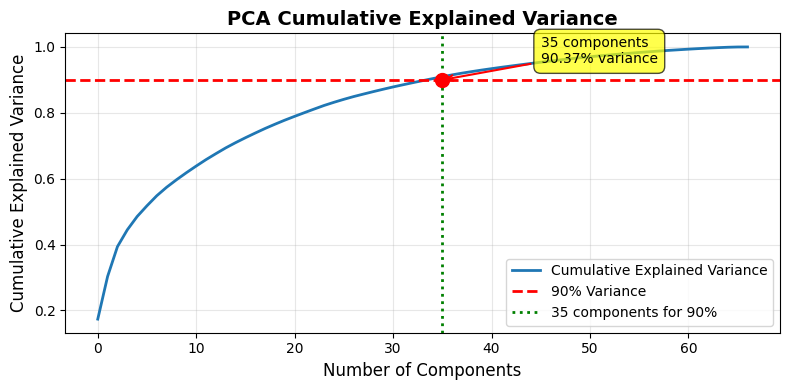

Number of components needed for 90% variance: 35
Actual variance explained: 0.9037


In [126]:
# Explained variance ratio and cumulative
exp_var_ratio = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

plt.figure(figsize=(8, 4))
plt.plot(cum_exp_var, linewidth=2, label='Cumulative Explained Variance')

# Add horizontal dotted line at 90%
plt.axhline(y=0.90, color='red', linestyle='--', linewidth=2, label='90% Variance')

# Optional: Add vertical line showing where 90% is reached
n_components_90 = np.argmax(cum_exp_var >= 0.90) + 1
plt.axvline(x=n_components_90, color='green', linestyle=':', linewidth=2,
            label=f'{n_components_90} components for 90%')

# Annotation showing the exact point
plt.scatter([n_components_90], [0.90], color='red', s=100, zorder=5)
plt.annotate(f'{n_components_90} components\n{cum_exp_var[n_components_90-1]:.2%} variance',
             xy=(n_components_90, 0.90),
             xytext=(n_components_90 + 10, 0.95),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.xlabel("Number of Components", fontsize=12)
plt.ylabel("Cumulative Explained Variance", fontsize=12)
plt.title("PCA Cumulative Explained Variance", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the number of components needed
print(f"Number of components needed for 90% variance: {n_components_90}")
print(f"Actual variance explained: {cum_exp_var[n_components_90-1]:.4f}")


In [127]:
# Re-apply PCA to the data while selecting for number of components to retain.

# choose k based on the curve above
n_components = 35

pca = PCA(n_components=n_components, random_state=42)
master_pca = pca.fit_transform(df_master_imputed_scaled)

print("Shape after PCA:", master_pca.shape)
print("Explained variance (cum):", pca.explained_variance_ratio_.sum())



Shape after PCA: (792287, 35)
Explained variance (cum): 0.9036886692429821


### Discussion 2.2: Perform Dimensionality Reduction


- PCA reduced our data dimensions to almost the half (**35** componants) that explain 90% of the data variance.

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [128]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.



In [129]:
import numpy as np
import pandas as pd

# Assume:
# - df_master_imputed_scaled is your scaled input DataFrame (columns = features)
# - pca is your fitted PCA object

feature_names = df_master.columns
components = pca.components_          # shape (n_components, n_features)

def print_sorted_loadings(pca, feature_names, comp_idx=0, top_n=10):
    """
    Print top positive and negative loadings for component comp_idx (0-based).
    """
    # loadings for this component
    loadings = pca.components_[comp_idx]

    # make a Series: index = feature names, values = weights
    s = pd.Series(loadings, index=feature_names)

    # sort by weight
    s_sorted = s.sort_values(ascending=False)

    print(f"\nComponent {comp_idx+1} – top +{top_n}:")
    print(s_sorted.head(top_n))

    print(f"\nComponent {comp_idx+1} – top -{top_n}:")
    print(s_sorted.tail(top_n))




In [130]:
# example: first 3 principal components
for i in range(3):
    print_sorted_loadings(pca, feature_names, comp_idx=i, top_n=10)


Component 1 – top +10:
movement_patterns             0.237215
plz8_1_2_family_homes         0.225882
microcell_1_2_family_homes    0.216604
microcell_num_buildings       0.211772
financial_minimalist          0.199574
distance_to_retail            0.169828
plz8_num_buildings            0.167597
distance_to_city_center       0.167257
life_stage_fine               0.145140
life_stage_rough              0.131292
dtype: float64

Component 1 – top -10:
microcell_10plus_family_homes   -0.153502
plz8_3_5_family_homes           -0.154502
financial_homeowner             -0.163736
household_income_score          -0.194264
household_density               -0.199396
cameo_wealth                    -0.200705
community_size                  -0.201701
plz8_building_type              -0.215627
plz8_10plus_family_homes        -0.220748
plz8_6_10_family_homes          -0.226741
dtype: float64

Component 2 – top +10:
age_category_rough            0.272183
financial_prepared            0.244595
personalit

### Discussion 2.3: Interpret Principal Components

The three components capture (1) urban residential form and affluence, (2) value‑ and lifestyle‑orientation, and (3) gendered, assertive vs. traditional personalities.​

Component 1: Suburban mobile vs. dense affluent
-----------------------------------------------

-   High scores: Areas with more movement_patterns, many 1--2‑family homes at both PLZ8 and microcell levels, more buildings overall, greater distance from retail and city centers, and later life stages. This describes more suburban, lower‑density neighborhoods with active mobility and family‑home--dominated housing stock.​

-   Low scores: Areas with higher shares of 3--10+‑family homes, higher household income scores, stronger CAMEO wealth, larger community size, denser building types, and more households per building. This reflects dense, higher‑income, urban or large‑town environments with multi‑family housing and stronger economic power.​

Interpretation: Component 1 contrasts suburban, mobile, dispersed family‑home regions (high scores) against dense, affluent, urban multi‑family areas (low scores).​

Component 2: Hedonistic/event‑oriented vs. dutiful/saver
--------------------------------------------------------

-   High scores: Older age categories, financially *prepared* but also more *minimalist*, more event‑oriented, sensual, critical, combative personalities, with higher return activity and greater likelihood of children. This suggests socially active, experience‑seeking, somewhat confrontational consumers with family responsibilities.​

-   Low scores: Youthful, financially *saving* and *investing*, inconspicuous, rational, religious, family‑minded, cultural, dutiful, and traditional. This indicates younger but conservative, disciplined savers and investors with strong family, duty, and religious orientations.​

Interpretation: Component 2 captures a spectrum from pleasure‑ and event‑oriented, expressive lifestyles (high) to conservative, religious, saving‑ and duty‑oriented lifestyles (low).​

Component 3: Male, dominant, investor vs. dreamy, relational, minimalist
------------------------------------------------------------------------

-   High scores: Male gender, combative, dominant, critical, rational, event‑oriented personalities, plus financial investor and saver/inconspicuous tendencies and youth decade. This aligns with younger, male‑dominated, assertive, achievement‑ and investment‑oriented profiles.​

-   Low scores: Religious, family‑ and socially‑minded, cultural, dreamful, children‑oriented, financially minimalist and prepared, with more returns. This reflects more relational, value‑driven, idealistic, and consumption‑cautious individuals, often with family focus.​

Interpretation: Component 3 contrasts assertive, male, investment‑oriented personalities (high) with religious, family‑ and community‑oriented, dreamy minimalists (low).​

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

Running K-Means to find optimal k...
k = 2, silhouette score = 0.1389
k = 3, silhouette score = 0.1136
k = 4, silhouette score = 0.0973
k = 5, silhouette score = 0.0987
k = 6, silhouette score = 0.0782
k = 7, silhouette score = 0.0910
k = 8, silhouette score = 0.0926
k = 9, silhouette score = 0.0887
k = 10, silhouette score = 0.0923
k = 11, silhouette score = 0.0880
k = 12, silhouette score = 0.0784
k = 13, silhouette score = 0.0824
k = 14, silhouette score = 0.0833
k = 15, silhouette score = 0.0808
k = 16, silhouette score = 0.0840
k = 17, silhouette score = 0.0754
k = 18, silhouette score = 0.0734
k = 19, silhouette score = 0.0679
k = 20, silhouette score = 0.0703
k = 21, silhouette score = 0.0703
k = 22, silhouette score = 0.0662
k = 23, silhouette score = 0.0721
k = 24, silhouette score = 0.0703


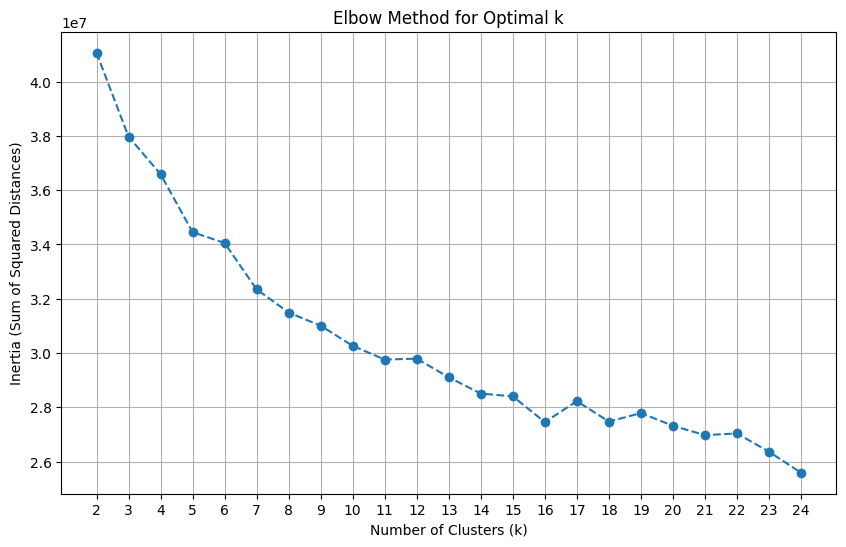


Best K depending on Silhoute score: K= 2


In [131]:
# Over a number of different cluster counts...

# run k-means clustering on the data and...

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Define a range of clusters to test
k_range = range(2, 25)  # Testing from 2 to 24 clusters
inertia_scores = []
sil_scores = []

print("Running K-Means to find optimal k...")

for k in k_range:
    # Using MiniBatchKMeans for speed during the search phase
    kmeans_test = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10)
    kmeans_test.fit(master_pca)
    inertia_scores.append(kmeans_test.inertia_)
    # Silhouette score (requires labels and the data)
    labels = kmeans_test.labels_
    sil = silhouette_score(master_pca, labels, metric="euclidean", sample_size=10000,   # or 20000, etc.
    random_state=42)      # for reproducibility
    sil_scores.append(sil)
    print(f"k = {k}, silhouette score = {sil:.4f}")

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()
print("\nBest K depending on Silhoute score: K=",sil_scores.index(max(sil_scores))+2)


In [132]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.

# Select the final number of clusters based on the plot (elbow point)
n_clusters = 2

# Fit the full KMeans model
kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10)
model_general = kmeans.fit(master_pca)

# Get cluster labels for the general population
general_preds = model_general.predict(master_pca)

print(f"Clustering complete. Data split into {n_clusters} clusters.")

Clustering complete. Data split into 2 clusters.


### Discussion 3.1: Apply Clustering to General Population


* Depending on elbow point graph and Silhoute score is the best number of clusters is 2 clusters.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [133]:
# Load in the customer demographics data.
customers = pd.read_csv("Udacity_CUSTOMERS_Subset.csv",sep=';')

In [134]:
customers.head(1)

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2,4,1,5.0,5,1,5,1,2,2,2,0,4.0,1,1,20.0,5.0,2.0,2.0,10.0,5.0,1,4,5.0,6,5,2,6,6,7,3,4,1,3,1,1,2,1,3,0.0,0.0,1,3,10.0,2.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,1.0,5.0,1992.0,W,7.0,1,1A,13,2.0,2.0,0.0,0.0,0.0,4.0,3.0,2.0,4.0,4.0,1.0,4.0,3.0,1.0,1201.0,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0


In [135]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.

customers_cleaned = clean_data(customers)

(191559, 26)


In [136]:
customers_cleaned.sample(3)

,age_category_rough,gender,financial_minimalist,financial_saver,financial_prepared,financial_investor,financial_inconspicuous,financial_homeowner,green_avantgarde,return_type,personality_socially_minded,personality_family_minded,personality_religious,personality_materialistic,personality_dreamful,personality_sensual,personality_event_oriented,personality_cultural,personality_rational,personality_critical,personality_dominant,personality_combative,personality_dutiful,personality_traditional,household_income_score,online_affinity
83542,3.0,2.0,4.0,2.0,4.0,5.0,2.0,1.0,0,NaN,1.0,1.0,3.0,2.0,4.0,4.0,6.0,1.0,4.0,4.0,4.0,5.0,5.0,4.0,2.0,NaN
165747,4.0,2.0,4.0,2.0,4.0,4.0,3.0,1.0,1,3.0,3.0,3.0,2.0,1.0,3.0,7.0,7.0,2.0,3.0,4.0,5.0,5.0,2.0,3.0,3.0,3.0
22859,4.0,1.0,5.0,1.0,5.0,1.0,1.0,3.0,1,5.0,6.0,6.0,5.0,4.0,7.0,7.0,3.0,4.0,1.0,3.0,3.0,2.0,4.0,4.0,2.0,3.0


In [137]:

# Reindex customers to match general data
customers_cleaned = customers_cleaned.reindex(columns=df_master.columns)

In [138]:
# Now verify shapes match
print(f"General data shape: {df_master.shape}")
print(f"Customer data shape: {customers_cleaned.shape}")
# The number of columns (2nd number) MUST be identical.

General data shape: (792287, 67)
Customer data shape: (191559, 67)


In [139]:

# transform on customer data

cu_imp = imputer.transform(customers_cleaned)
cu_scaled = scaler.transform(cu_imp)
cu_pca = pca.transform(cu_scaled)


In [140]:
# Predict Clusters (Use the kmeans object fitted on General Population)
customer_preds = kmeans.predict(cu_pca)

print("Customer data processed and clustered.")

Customer data processed and clustered.


### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

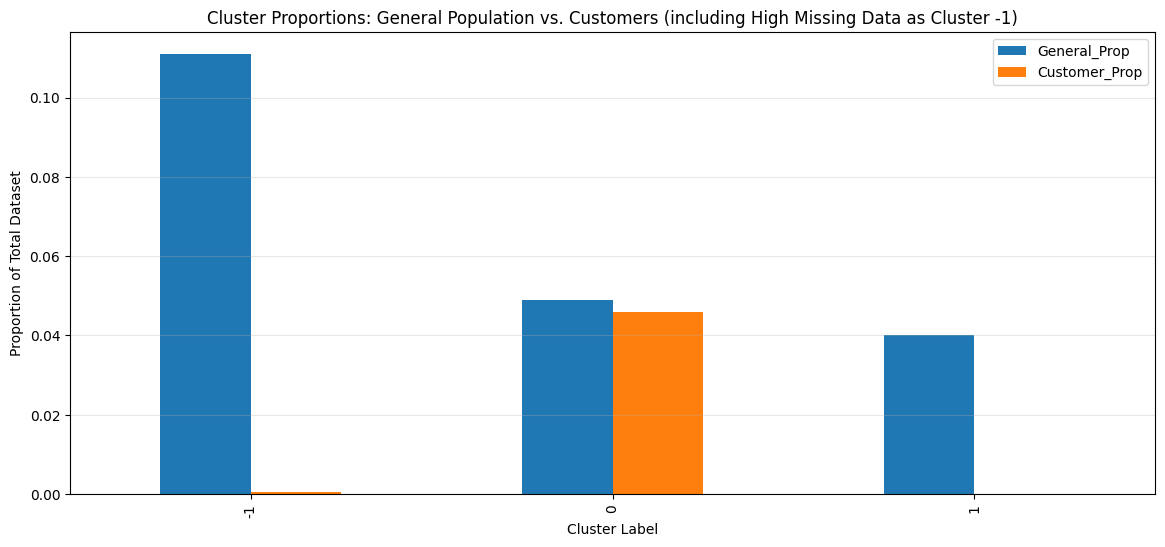

Cluster Representation Ratios (sorted by over-representation):
   Cluster  General_Prop  Customer_Prop  Overrepresentation_Ratio
1        0      0.048918       0.045791                  0.936078
0       -1      0.111010       0.000485                  0.004371
2        1      0.040163       0.000000                  0.000000


In [141]:

# Get counts for the "High Missing" data (the rows we dropped earlier)
# Recall: We split data based on a threshold (e.g., 20% missing)
threshold = 0.2

# For General Population
missing_per_row_gen = df_general.isnull().mean(axis=1)
count_high_missing_gen = np.sum(missing_per_row_gen > threshold)
count_low_missing_gen = np.sum(missing_per_row_gen <= threshold) # This matches len(general_preds)

# For Customers (Need to reload or calculate from original df before cleaning if not saved)
# Assuming 'customers' is the original raw dataframe loaded in 3.2
missing_per_row_cust = customers.isnull().mean(axis=1)
count_high_missing_cust = np.sum(missing_per_row_cust > threshold)
count_low_missing_cust = np.sum(missing_per_row_cust <= threshold) # This matches len(customer_preds)

# Total counts
total_gen = len(df_general)
total_cust = len(customers)

# Compile counts for all clusters (0 to k-1) PLUS the "-1" cluster (High Missing)
cluster_data = []

# Add High Missing Cluster (-1)
cluster_data.append({
    'Cluster': -1,
    'General_Prop': count_high_missing_gen / total_gen,
    'Customer_Prop': count_high_missing_cust / total_cust
})

# Add K-Means Clusters (0 to n_clusters-1)
# Note: We must scale the proportions by the fraction of low_missing data kept
gen_scale_factor = count_low_missing_gen / total_gen
cust_scale_factor = count_low_missing_cust / total_cust

for i in range(n_clusters):
    # Proportion within the low_missing subset * proportion of dataset that is low_missing
    prop_gen = (np.sum(general_preds == i) / len(general_preds)) * gen_scale_factor
    prop_cust = (np.sum(customer_preds == i) / len(customer_preds)) * cust_scale_factor

    cluster_data.append({
        'Cluster': i,
        'General_Prop': prop_gen,
        'Customer_Prop': prop_cust
    })

# Create DataFrame
cluster_comparison = pd.DataFrame(cluster_data)
cluster_comparison['Cluster'] = cluster_comparison['Cluster'].astype(int)

# 3. Plotting
fig, ax = plt.subplots(figsize=(14, 6))
cluster_comparison.plot(x='Cluster', y=['General_Prop', 'Customer_Prop'], kind='bar', ax=ax)
plt.title('Cluster Proportions: General Population vs. Customers (including High Missing Data as Cluster -1)')
plt.ylabel('Proportion of Total Dataset')
plt.xlabel('Cluster Label')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Calculate Over/Under Representation Ratio
# Avoid division by zero
cluster_comparison['Overrepresentation_Ratio'] = cluster_comparison['Customer_Prop'] / cluster_comparison['General_Prop']
print("Cluster Representation Ratios (sorted by over-representation):")
print(cluster_comparison.sort_values(by='Overrepresentation_Ratio', ascending=False))

In [142]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

# 1. Identify the most overrepresented modeled cluster (excluding the "missing" -1 bucket)
# In our cluster_comparison, the missing data is labeled as Cluster -1
valid_cluster_summary  = cluster_comparison[cluster_comparison['Cluster'] != -1]
most_overrepresented_cluster_id  = int(valid_cluster_summary .loc[valid_cluster_summary ['Overrepresentation_Ratio'].idxmax(), 'Cluster'])

print(f"Most overrepresented cluster (by ratio): Cluster {most_overrepresented_cluster_id }")

# 2. Back-project centroid to scaled-feature space (z-scores relative to global mean)
# Note: pca.inverse_transform returns values in the standardized scale (Z-scores)
# because the PCA was fit on df_master_imputed_scaled.
overrepresented_cluster_zscores  = pd.Series(
    pca.inverse_transform(model_general.cluster_centers_[most_overrepresented_cluster_id ]),
    index=df_master.columns # Using the column names from the cleaned dataframe
)

# 3. Sort and Display Top Positive and Negative Z-Scores
sorted_zscores_overrepresented = overrepresented_cluster_zscores .sort_values()

print(f"\nCluster {most_overrepresented_cluster_id} top negative feature z-scores (Lower than population average):")
print(sorted_zscores_overrepresented.head(12).round(3))

print(f"\nCluster {most_overrepresented_cluster_id} top positive feature z-scores (Higher than population average):")
print(sorted_zscores_overrepresented.tail(12).round(3))

Most overrepresented cluster (by ratio): Cluster 0

Cluster 0 top negative feature z-scores (Lower than population average):
personality_cultural          -0.910
personality_dreamful          -0.909
personality_family_minded     -0.889
personality_religious         -0.709
personality_socially_minded   -0.685
personality_materialistic     -0.594
financial_minimalist          -0.587
microcell_1_2_family_homes    -0.496
movement_patterns             -0.433
personality_traditional       -0.426
children_likelihood           -0.342
neighborhood_quality          -0.340
dtype: float64

Cluster 0 top positive feature z-scores (Higher than population average):
unemployment_relative          0.368
plz8_6_10_family_homes         0.408
cameo_wealth                   0.504
plz8_3_5_family_homes          0.581
microcell_6_10_family_homes    0.585
microcell_3_5_family_homes     0.619
household_income_score         0.650
personality_critical           0.761
personality_event_oriented     0.816
gender  

### Discussion 3.3: Compare Customer Data to Demographics Data

Based on the inverse transform and the resulting Z-scores for **Cluster 0** (the overrepresented segment), we can develop a clear profile of the individuals who are most likely to be customers of the mail-order company.

### 1\. The Overrepresented Segment (Core Customers)

This segment is characterized by a "strong/assertive" personality profile and higher financial status.

-   **Personality Profile (The "Assertive" Type):** This is the most striking characteristic. Customers have very high positive Z-scores for being **combative (1.022)**, **dominant (0.959)**, **event-oriented (0.816)**, and **critical (0.761)**. Conversely, they score very low (high negative Z-scores) on being **cultural (-0.910)**, **dreamful (-0.909)**, and **family-minded (-0.889)**. This suggests the target audience is less emotionally driven and more rational or action-oriented.

-   **Gender:** With a high positive Z-score for **gender (0.941)**, and assuming the typical encoding where 1 is female and 2 is male (or vice versa depending on your specific mapping), this segment shows a strong skew toward one specific gender.

-   **Financial & Social Status:** These are affluent individuals. They have high **household_income_scores (0.650)** and **cameo_wealth (0.504)**. They are notably **not** "financial minimalists" (-0.587), meaning they have high purchasing power and a higher interest in financial investments or consumption.

-   **Living Environment:** They tend to live in areas with **3--10 family homes** (PLZ8 and microcell features). They are less likely to live in single or two-family homes (-0.496), suggesting an urban or densely populated suburban environment rather than isolated rural areas.

### 2\. The Underrepresented Segment (Unpopular with the Company)

By looking at what Cluster 0 is *not*, we can infer the profile of the segment that is relatively unpopular with the company (likely the opposite of the above):

-   **Socially and Family Oriented:** People who rank high in being **cultural**, **religious**, **dreamful**, and **family-minded** are significantly less likely to be customers.

-   **Lower Affluence:** Individuals who are **financial minimalists** or have lower household income scores are not the primary target.

-   **Younger Families:** The negative Z-score for **children_likelihood (-0.342)** suggests that the company is less popular with young families or households where children are a primary focus.

-   **Rural Residents:** Those living in neighborhoods dominated by small 1--2 family houses (negative Z-score for microcell_1_2_family_homes) are underrepresented.

### Summary Conclusion

The mail-order company is **highly successful** with **affluent, urban-dwelling individuals who possess assertive, rational, and dominant personalities.** These customers likely value efficiency, status, and high-quality products over sentimental or traditional values.

Conversely, the company is **less popular** with **traditionalists, family-oriented individuals, and those with lower income or minimalist financial habits.** To grow their market share, the company would either need to adjust its product catalog to appeal to more "family-minded" and "cultural" interests or double down on its current high-income, assertive demographic.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.